In [82]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap,LinearSegmentedColormap
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

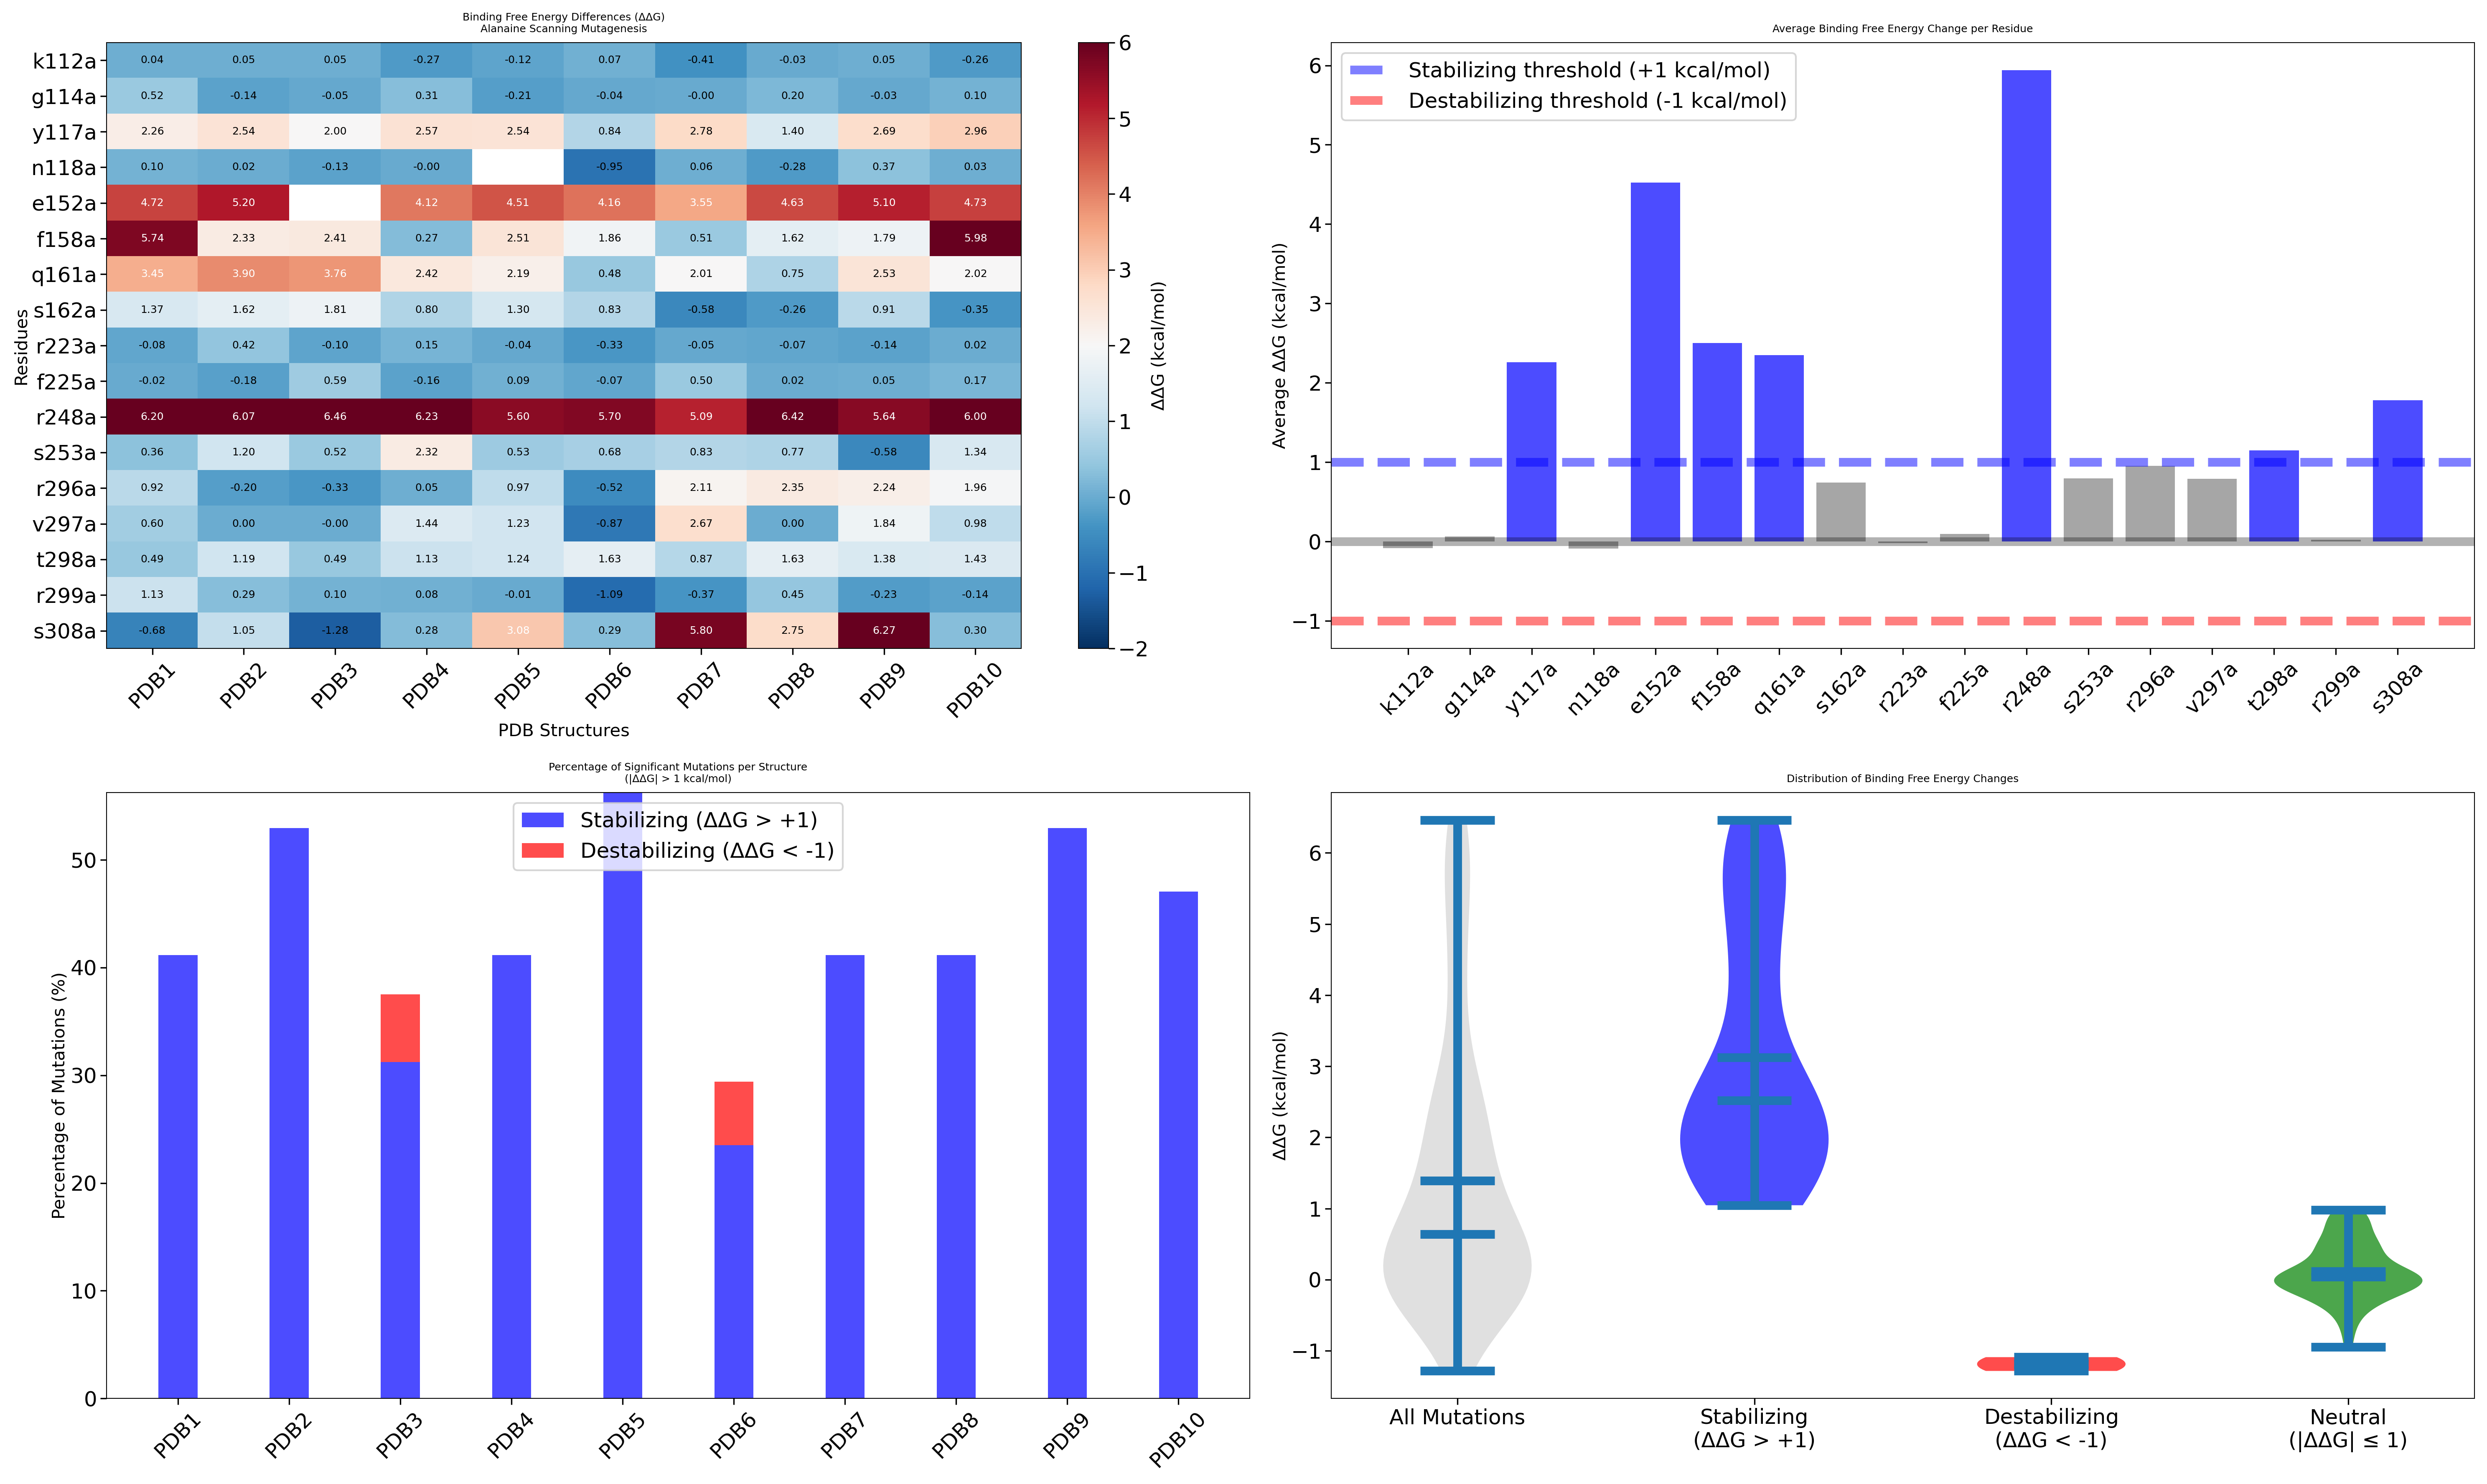

Total mutations analyzed: 168
Stabilizing mutations (ΔΔG > +1 kcal/mol): 72 (42.9%)
Destabilizing mutations (ΔΔG < -1 kcal/mol): 2 (1.2%)
Neutral mutations (|ΔΔG| ≤ 1 kcal/mol): 94 (56.0%)

Most stabilizing residue on average: r248a (5.94 kcal/mol)
Most destabilizing residue on average: n118a (-0.09 kcal/mol)


In [83]:
# Parse the data
data = """
k112a  0.037730  0.053490  0.048730  -0.26792  -0.11551  0.066460  -0.41187  -0.02820  0.050080  -0.26373
g114a  0.515760  -0.13609  -0.05350  0.307410  -0.20895  -0.03579  -0.00190  0.20359   -0.03465  0.104680
y117a  2.260650  2.544640  2.001700  2.573910  2.541470  0.835820  2.775570  1.403950  2.692670  2.957100
n118a  0.100580  0.016730  -0.12642  -0.00292  xxx       -0.94628  0.056770  -0.27990  0.373090  0.031390
e152a  4.715920  5.197170  xxx        4.116890  4.509750  4.163670  3.554750  4.63250   5.096400  4.734680
f158a  5.744370  2.328750  2.405240  0.267300  2.512050  1.859510  0.507850  1.618560  1.793670  5.975340
q161a  3.453530  3.903070  3.760710  2.418150  2.192340  0.479740  2.006090  0.751330  2.527560  2.019430
s162a  1.365590  1.619340  1.811790  0.803880  1.301030  0.834700  -0.58403  -0.26383  0.914360  -0.35188
r223a  -0.08032  0.418740  -0.09608  0.147360  -0.03856  -0.33004  -0.04666  -0.06569  -0.14290  0.018070
f225a  -0.01585  -0.18422  0.59061   -0.15612  0.089360  -0.07465  0.502810  0.02170   0.04560   0.166890
r248a  6.198860  6.066370  6.461520  6.229610  5.597990  5.700840  5.09260   6.415800  5.643070  6.003660
s253a  0.357410  1.195720  0.515780  2.317120  0.534990  0.677650  0.827730  0.767490  -0.58420  1.344230
r296a  0.916100  -0.20439  -0.33240  0.04661   0.970000  -0.51692  2.111960  2.354520  2.238830  1.963190
v297a  0.595480  0.0       -0.0      1.442790  1.229340  -0.86506  2.665560  0.0       1.838670  0.981230
t298a  0.488260  1.192790  0.485530  1.127900  1.243570  1.626000  0.873960  1.628960  1.382670  1.434540
r299a  1.132700  0.28723   0.102310  0.084510  -0.01292  -1.08969  -0.36688  0.447170  -0.22697  -0.14012
s308a  -0.68341  1.046010  -1.28373  0.277510  3.078640  0.285090  5.802390  2.745340  6.266090  0.298510
"""

# Process the data
lines = data.strip().split('\n')
residues = []
values = []

for line in lines:
    parts = line.split()
    residue = parts[0]
    residue_values = []
    for val in parts[1:]:
        if val == 'xxx':
            residue_values.append(np.nan)
        else:
            residue_values.append(float(val))
    residues.append(residue)
    values.append(residue_values)

values = np.array(values)
structures = [f'PDB{i+1}' for i in range(values.shape[1])]

# Create the figure with subplots
fig = plt.figure(figsize=(20, 12))

# 1. Heatmap of all ΔΔG values
plt.subplot(2, 2, 1)
masked_values = np.ma.array(values, mask=np.isnan(values))
im = plt.imshow(masked_values, cmap='RdBu_r', aspect='auto', vmin=-2, vmax=6)
plt.colorbar(im, label='ΔΔG (kcal/mol)')
plt.xticks(range(len(structures)), structures, rotation=45)
plt.yticks(range(len(residues)), residues)
plt.title('Binding Free Energy Differences (ΔΔG)\nAlanaine Scanning Mutagenesis')
plt.xlabel('PDB Structures')
plt.ylabel('Residues')

# Add value annotations
for i in range(len(residues)):
    for j in range(len(structures)):
        if not np.isnan(values[i, j]):
            plt.text(j, i, f'{values[i, j]:.2f}', ha='center', va='center', 
                    fontsize=6, color='white' if abs(values[i, j]) > 3 else 'black')

# 2. Bar plot of average ΔΔG per residue
plt.subplot(2, 2, 2)
avg_ddg = np.nanmean(values, axis=1)
colors = ['red' if x < -1 else 'blue' if x > 1 else 'gray' for x in avg_ddg]
bars = plt.bar(range(len(residues)), avg_ddg, color=colors, alpha=0.7)
plt.axhline(y=1, color='blue', linestyle='--', alpha=0.5, label='Stabilizing threshold (+1 kcal/mol)')
plt.axhline(y=-1, color='red', linestyle='--', alpha=0.5, label='Destabilizing threshold (-1 kcal/mol)')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.xticks(range(len(residues)), residues, rotation=45)
plt.ylabel('Average ΔΔG (kcal/mol)')
plt.title('Average Binding Free Energy Change per Residue')
plt.legend()

# 3. Distribution of significant mutations per structure
plt.subplot(2, 2, 3)
stabilizing_count = np.sum(values > 1, axis=0)
destabilizing_count = np.sum(values < -1, axis=0)
total_residues = np.sum(~np.isnan(values), axis=0)

stabilizing_percent = (stabilizing_count / total_residues) * 100
destabilizing_percent = (destabilizing_count / total_residues) * 100

x = range(len(structures))
width = 0.35
plt.bar(x, stabilizing_percent, width, label='Stabilizing (ΔΔG > +1)', color='blue', alpha=0.7)
plt.bar(x, destabilizing_percent, width, bottom=stabilizing_percent, 
        label='Destabilizing (ΔΔG < -1)', color='red', alpha=0.7)

plt.xticks(x, structures, rotation=45)
plt.ylabel('Percentage of Mutations (%)')
plt.title('Percentage of Significant Mutations per Structure\n(|ΔΔG| > 1 kcal/mol)')
plt.legend()

# 4. Violin plot showing distribution of ΔΔG values
plt.subplot(2, 2, 4)
ddg_flat = values[~np.isnan(values)].flatten()
significant_pos = ddg_flat[ddg_flat > 1]
significant_neg = ddg_flat[ddg_flat < -1]
neutral = ddg_flat[(ddg_flat >= -1) & (ddg_flat <= 1)]

categories = ['All Mutations', 'Stabilizing\n(ΔΔG > +1)', 'Destabilizing\n(ΔΔG < -1)', 'Neutral\n(|ΔΔG| ≤ 1)']
data_to_plot = [ddg_flat, significant_pos, significant_neg, neutral]

violin = plt.violinplot(data_to_plot, showmeans=True, showmedians=True)
plt.xticks(range(1, len(categories) + 1), categories)
plt.ylabel('ΔΔG (kcal/mol)')
plt.title('Distribution of Binding Free Energy Changes')

# Color the violin plots
for i, pc in enumerate(violin['bodies']):
    if i == 0:  # All mutations
        pc.set_facecolor('lightgray')
    elif i == 1:  # Stabilizing
        pc.set_facecolor('blue')
    elif i == 2:  # Destabilizing
        pc.set_facecolor('red')
    else:  # Neutral
        pc.set_facecolor('green')
    pc.set_alpha(0.7)

plt.tight_layout()
plt.show()

# Print some statistics
print(f"Total mutations analyzed: {len(ddg_flat)}")
print(f"Stabilizing mutations (ΔΔG > +1 kcal/mol): {len(significant_pos)} ({len(significant_pos)/len(ddg_flat)*100:.1f}%)")
print(f"Destabilizing mutations (ΔΔG < -1 kcal/mol): {len(significant_neg)} ({len(significant_neg)/len(ddg_flat)*100:.1f}%)")
print(f"Neutral mutations (|ΔΔG| ≤ 1 kcal/mol): {len(neutral)} ({len(neutral)/len(ddg_flat)*100:.1f}%)")
print(f"\nMost stabilizing residue on average: {residues[np.nanargmax(avg_ddg)]} ({np.nanmax(avg_ddg):.2f} kcal/mol)")
print(f"Most destabilizing residue on average: {residues[np.nanargmin(avg_ddg)]} ({np.nanmin(avg_ddg):.2f} kcal/mol)")

In [84]:
plt.rcParams.update({
    'font.size':12,
    'axes.labelsize':10,
    'axes.titlesize':6,
    'legend.fontsize':12,
    'xtick.labelsize':12,
    'ytick.labelsize':12,
    'figure.dpi':300,
    'savefig.dpi':300,
    'axes.linewidth':0.5,
    'lines.linewidth':5,
})
plt.rcParams['axes.labelpad'] = 1     # 坐标轴标签距离
plt.rcParams['xtick.major.pad'] = 2     # X轴主刻度标签距离
plt.rcParams['ytick.major.pad'] = 2     # Y轴主刻度标签距离
plt.rcParams['axes.titlepad'] = 6      # 标题距离

In [85]:
cm = 1/2.54

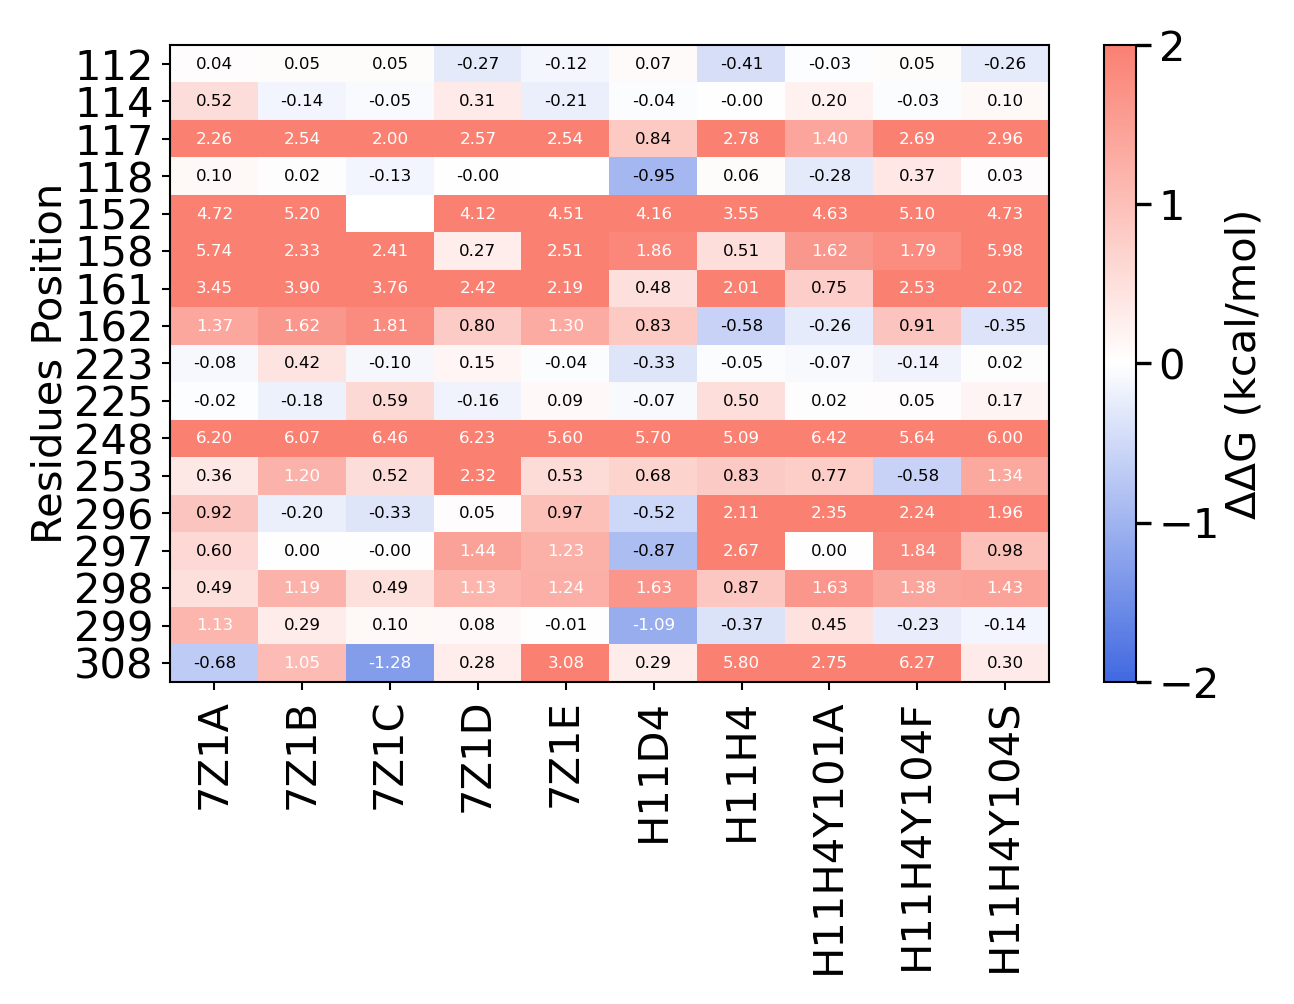

In [80]:

data = """
112  0.037730  0.053490  0.048730  -0.26792  -0.11551  0.066460  -0.41187  -0.02820  0.050080  -0.26373
114  0.515760  -0.13609  -0.05350  0.307410  -0.20895  -0.03579  -0.00190  0.20359   -0.03465  0.104680
117  2.260650  2.544640  2.001700  2.573910  2.541470  0.835820  2.775570  1.403950  2.692670  2.957100
118  0.100580  0.016730  -0.12642  -0.00292  xxx       -0.94628  0.056770  -0.27990  0.373090  0.031390
152  4.715920  5.197170  xxx        4.116890  4.509750  4.163670  3.554750  4.63250   5.096400  4.734680
158  5.744370  2.328750  2.405240  0.267300  2.512050  1.859510  0.507850  1.618560  1.793670  5.975340
161  3.453530  3.903070  3.760710  2.418150  2.192340  0.479740  2.006090  0.751330  2.527560  2.019430
162  1.365590  1.619340  1.811790  0.803880  1.301030  0.834700  -0.58403  -0.26383  0.914360  -0.35188
223  -0.08032  0.418740  -0.09608  0.147360  -0.03856  -0.33004  -0.04666  -0.06569  -0.14290  0.018070
225  -0.01585  -0.18422  0.59061   -0.15612  0.089360  -0.07465  0.502810  0.02170   0.04560   0.166890
248  6.198860  6.066370  6.461520  6.229610  5.597990  5.700840  5.09260   6.415800  5.643070  6.003660
253  0.357410  1.195720  0.515780  2.317120  0.534990  0.677650  0.827730  0.767490  -0.58420  1.344230
296  0.916100  -0.20439  -0.33240  0.04661   0.970000  -0.51692  2.111960  2.354520  2.238830  1.963190
297  0.595480  0.0       -0.0      1.442790  1.229340  -0.86506  2.665560  0.0       1.838670  0.981230
298  0.488260  1.192790  0.485530  1.127900  1.243570  1.626000  0.873960  1.628960  1.382670  1.434540
299  1.132700  0.28723   0.102310  0.084510  -0.01292  -1.08969  -0.36688  0.447170  -0.22697  -0.14012
308  -0.68341  1.046010  -1.28373  0.277510  3.078640  0.285090  5.802390  2.745340  6.266090  0.298510
"""

# Process the data
lines = data.strip().split('\n')
residues = []
values = []

for line in lines:
    parts = line.split()
    residue = parts[0]
    residue_values = []
    for val in parts[1:]:
        if val == 'xxx':
            residue_values.append(np.nan)
        else:
            residue_values.append(float(val))
    residues.append(residue)
    values.append(residue_values)

values = np.array(values)
structures = ["7Z1A", "7Z1B", "7Z1C", "7Z1D", "7Z1E", "H11D4", "H11H4", "H11H4Y101A", "H11H4Y104F","H11H4Y104S"]

# Create the figure with subplots
fig = plt.figure(figsize=(12*cm, 7*cm),dpi=300)

plt.tick_params(axis='both', which='major', width=0.5, length=2)
# 1. Heatmap of all ΔΔG values
masked_values = np.ma.array(values, mask=np.isnan(values))
#cmap = LinearSegmentedColormap.from_list('mycmap',[(0, 'b'),(0.25,'white'),(0.5,'lightsalmon'),(0.75, 'tomato'),(1, 'red')])
cmap = LinearSegmentedColormap.from_list('mycmap',[(0, 'royalblue'),(0.5,'white'),(1, 'salmon')])
im = plt.imshow(masked_values, cmap=cmap, aspect='auto', vmin=-2, vmax=2)
cbar=plt.colorbar(im, label='ΔΔG (kcal/mol)')
cbar.ax.tick_params(labelsize=10)
cbar.set_label('ΔΔG (kcal/mol)', size=10)

plt.xticks(range(len(structures)), structures, rotation=90,fontsize=10)
plt.yticks(range(len(residues)), residues,fontsize=10)
#plt.title('Binding Free Energy Differences (ΔΔG)',fontsize=8)
#plt.xlabel('PDB Structures')
plt.ylabel('Residues Position',fontsize=10)

# Add value annotations
for i in range(len(residues)):
    for j in range(len(structures)):
        if not np.isnan(values[i, j]):
            plt.text(j, i, f'{values[i, j]:.2f}', ha='center', va='center', 
                    fontsize=4, color='white' if abs(values[i, j]) > 1 else 'black')
plt.savefig('/home/teliu/work/nanobody/image/hotspot/7z1x.png',bbox_inches='tight',transparent=True)

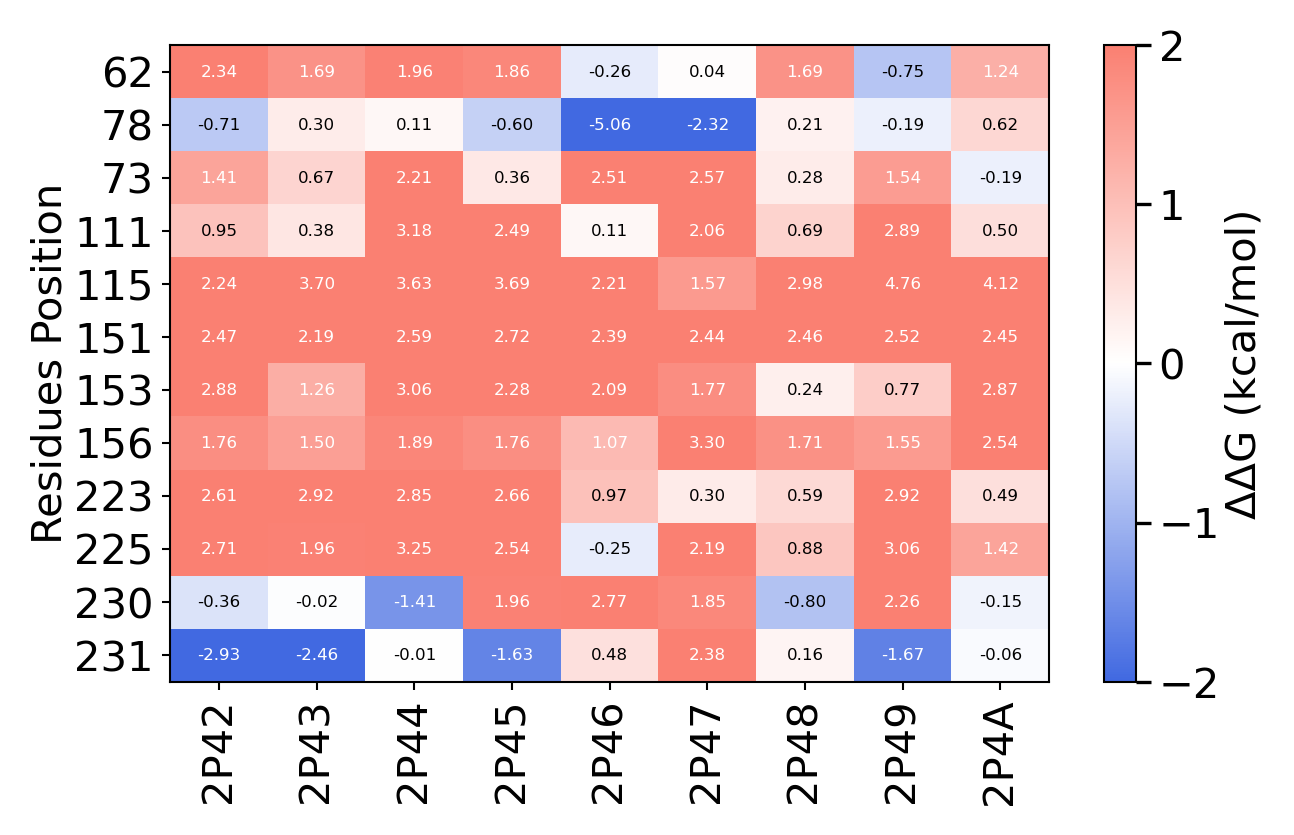

In [81]:
# Parse the data for 2P42
data = """
62  | 2.34034  | 1.690620 | 1.962170 | 1.860570 | -0.26144 | 0.036580 | 1.691610 | -0.75132 | 1.241160
78  | -0.71175 | 0.296100 | 0.111960 | -0.60184 | -5.06415 | -2.31892 | 0.21270  | -0.19399 | 0.622360
73  | 1.409200 | 0.667760 | 2.210740 | 0.359190 | 2.508580 | 2.568570 | 0.282410 | 1.535740 | -0.18993
111 | 0.949450 | 0.375910 | 3.181100 | 2.491130 | 0.111210 | 2.063550 | 0.685350 | 2.88616  | 0.502470
115 | 2.238970 | 3.700490 | 3.633500 | 3.689870 | 2.208480 | 1.569950 | 2.982690 | 4.758830 | 4.117300
151 | 2.469980 | 2.191260 | 2.586190 | 2.716140 | 2.390410 | 2.442180 | 2.46222  | 2.515220 | 2.449620
153 | 2.883900 | 1.263510 | 3.056470 | 2.284300 | 2.092370 | 1.770390 | 0.241780 | 0.769770 | 2.868180
156 | 1.759220 | 1.495020 | 1.885930 | 1.76030  | 1.066090 | 3.30010  | 1.708370 | 1.551250 | 2.542220
223 | 2.605270 | 2.921070 | 2.851680 | 2.658890 | 0.968340 | 0.298250 | 0.588090 | 2.918270 | 0.489050
225 | 2.707430 | 1.960790 | 3.249370 | 2.539150 | -0.24580 | 2.19473  | 0.881060 | 3.060600 | 1.41568
230 | -0.36485 | -0.01858 | -1.41470 | 1.956810 | 2.773380 | 1.848220 | -0.80319 | 2.26104  | -0.15311
231 | -2.92753 | -2.45596 | -0.01177 | -1.62787 | 0.480000 | 2.378170 | 0.163120 | -1.66519 | -0.055960
"""

# Process the data
lines = data.strip().split('\n')
residues = []
values = []

for line in lines:
    parts = [p.strip() for p in line.split('|')]
    residue = parts[0]
    residue_values = [float(val) for val in parts[1:]]
    residues.append(residue)
    values.append(residue_values)

values = np.array(values)
structures = ["2P42", "2P43", "2P44", "2P45", "2P46", "2P47", "2P48", "2P49", "2P4A"]

# Create the figure with the same 4-panel layout as before
fig = plt.figure(figsize=(12*cm, 7*cm),dpi=300)
plt.tick_params(axis='both', which='major', width=0.5, length=2)


# 1. Heatmap of all ΔΔG values
#cmap = LinearSegmentedColormap.from_list('mycmap',[(0, 'b'),(0.25,'white'),(0.5,'lightsalmon'),(0.75, 'tomato'),(1, 'red')])
cmap = LinearSegmentedColormap.from_list('mycmap',[(0, 'royalblue'),(0.5,'white'),(1, 'salmon')])
im = plt.imshow(values, cmap=cmap, aspect='auto', vmin=-2, vmax=2)
cbar=plt.colorbar(im, label='ΔΔG (kcal/mol)')
cbar.ax.tick_params(labelsize=10)
cbar.set_label('ΔΔG (kcal/mol)', size=10)

plt.xticks(range(len(structures)), structures, rotation=90,fontsize=10)
plt.yticks(range(len(residues)), residues,fontsize=10)
#plt.title('Binding Free Energy Differences (ΔΔG)',fontsize=8)
#plt.xlabel('PDB Structures')
plt.ylabel('Residues Position',fontsize=10)

# Add value annotations
for i in range(len(residues)):
    for j in range(len(structures)):
        plt.text(j, i, f'{values[i, j]:.2f}', ha='center', va='center', 
                fontsize=4, color='white' if abs(values[i, j]) > 1 else 'black')
plt.savefig('/home/teliu/work/nanobody/image/hotspot/2p4x.png',bbox_inches='tight',transparent=True)

/tmp/ipykernel_12075/4234565975.py:126: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([tz1a_avg, p42_avg], labels=['TZ1A', '2P42'])
/tmp/ipykernel_12075/4234565975.py:166: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([tz1a_std, p42_std], labels=['TZ1A', '2P42'])


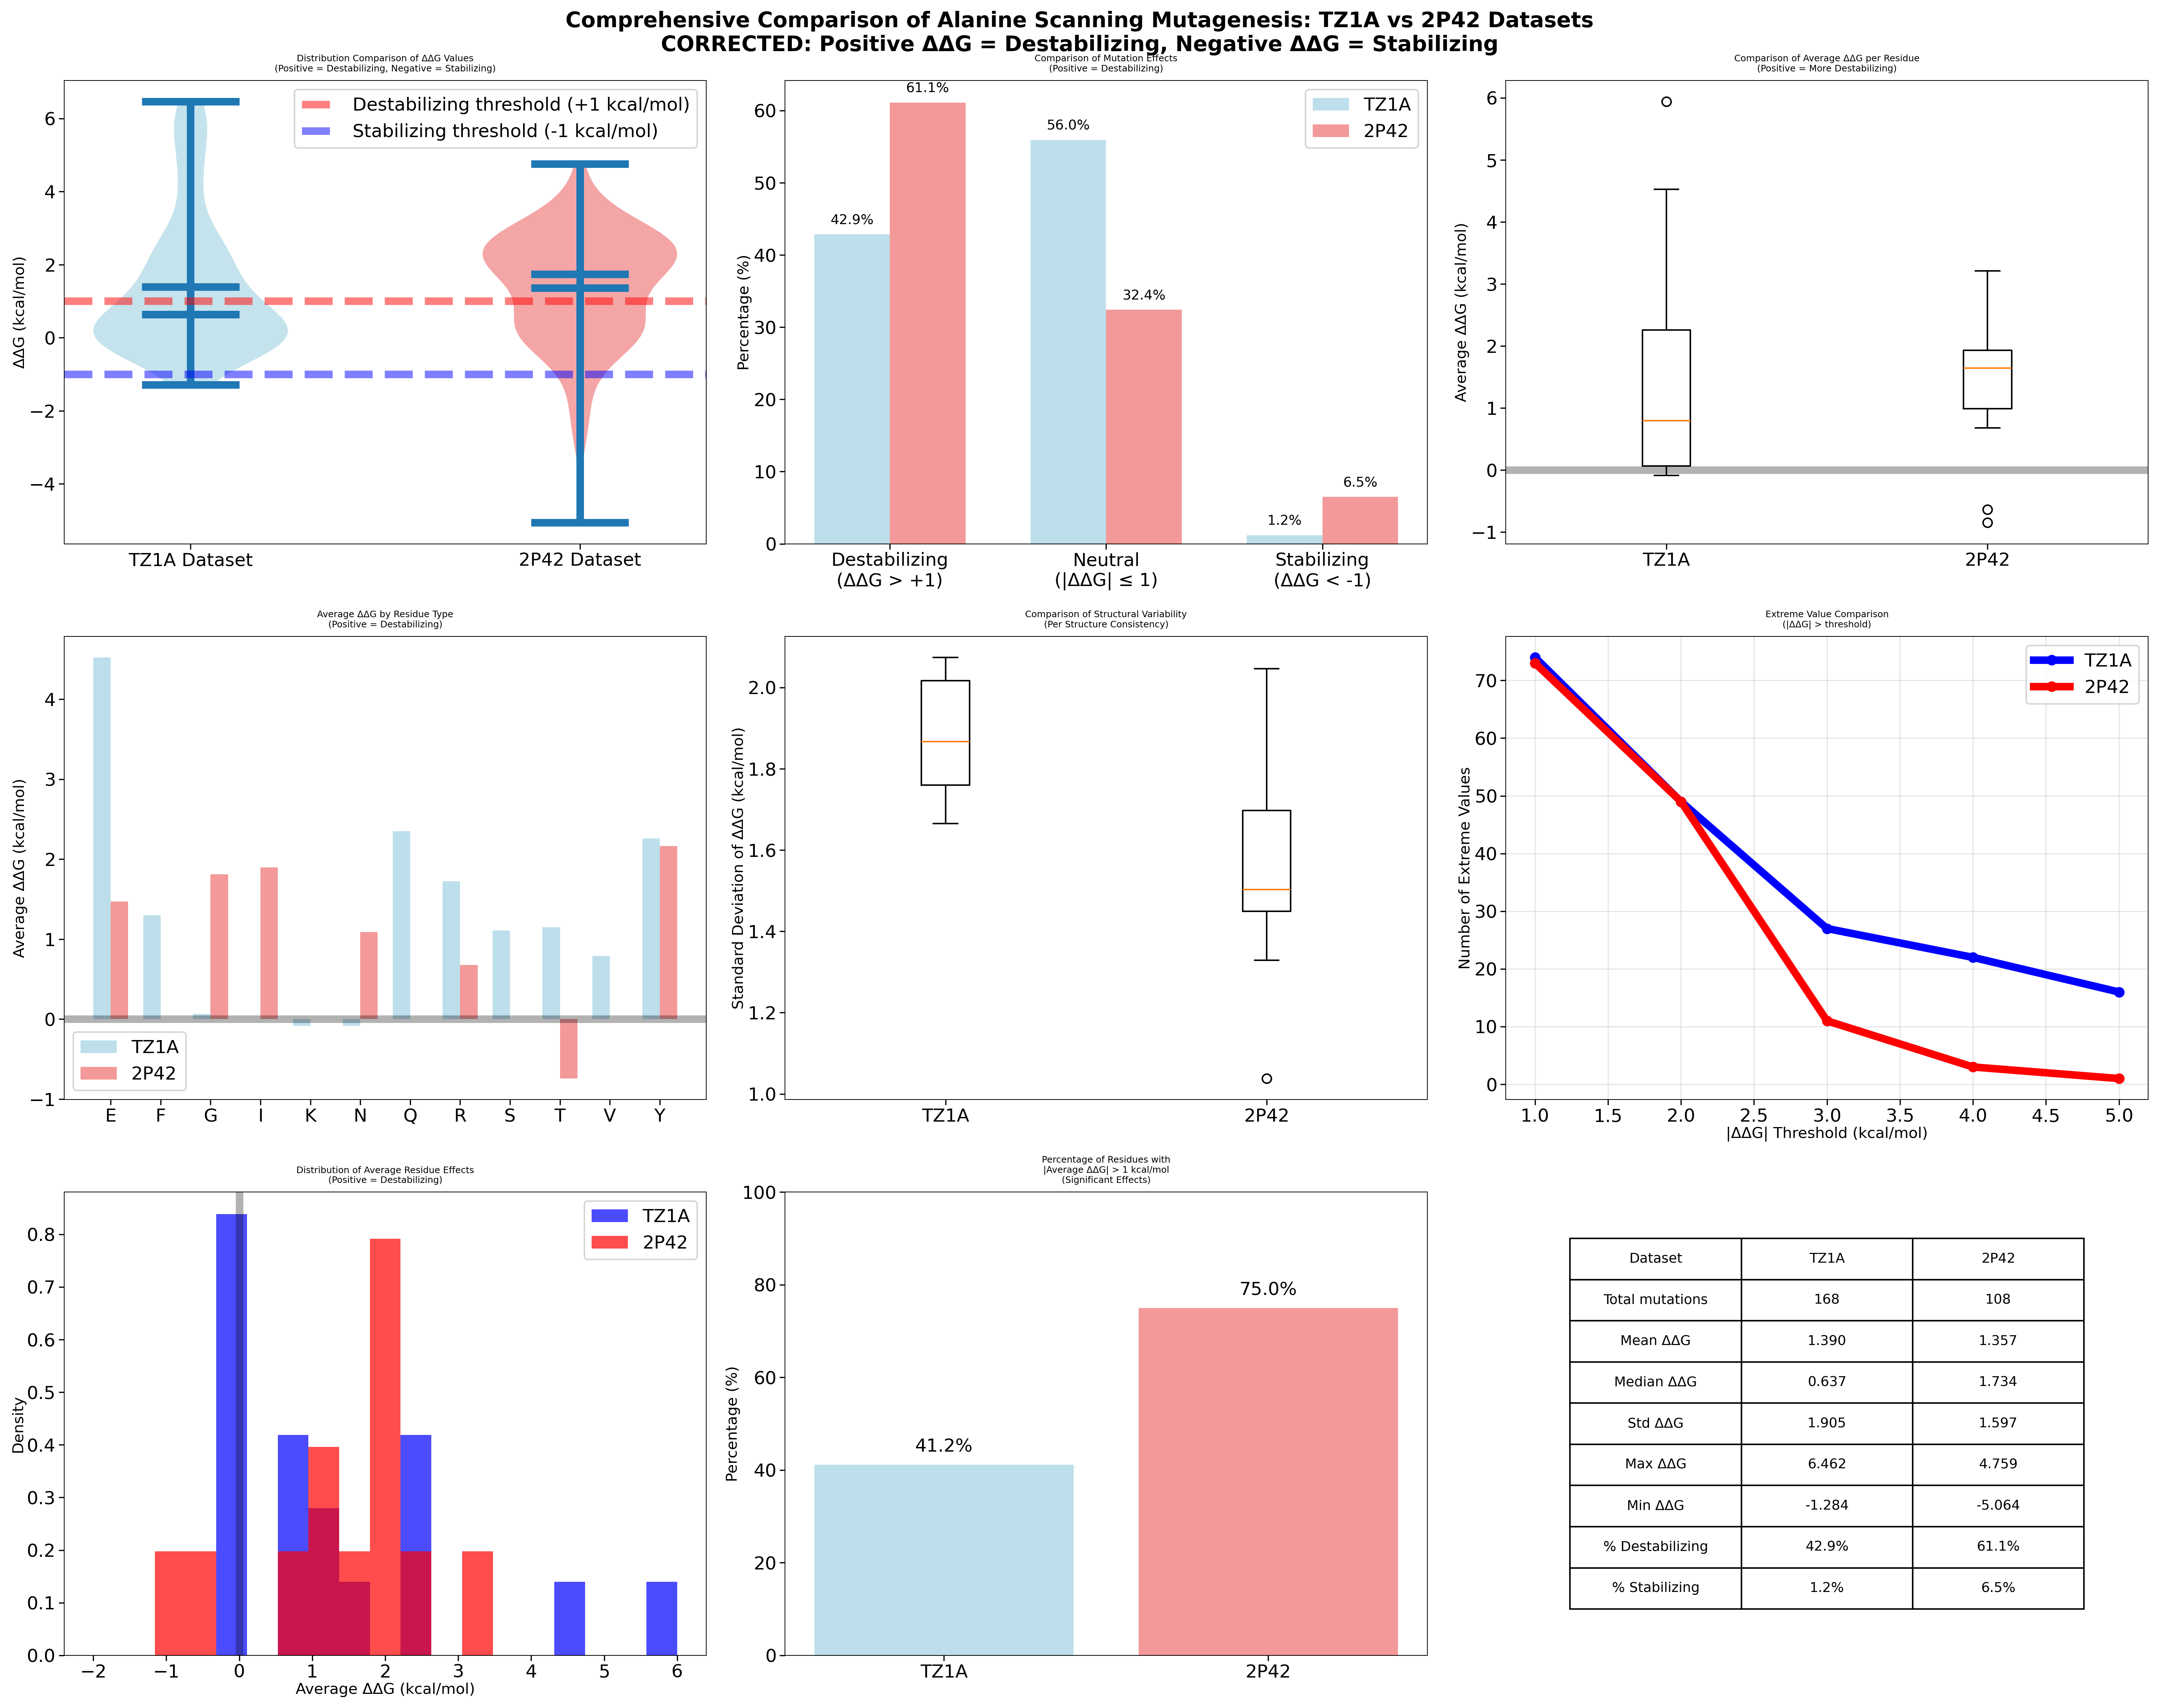

COMPARISON INSIGHTS - CORRECTED INTERPRETATION
NOTE: Positive ΔΔG = DESTABILIZING (unfavorable)
      Negative ΔΔG = STABILIZING (favorable)

1. DATA SIZE:
   TZ1A: 168 mutations across 10 structures
   2P42: 108 mutations across 9 structures

2. OVERALL EFFECT DIRECTION:
   TZ1A - Mean ΔΔG: 1.390 kcal/mol (positive = net destabilizing)
   2P42 - Mean ΔΔG: 1.357 kcal/mol (positive = net destabilizing)

3. SIGNIFICANT MUTATIONS:
   TZ1A: 41.2% of residues show significant effects (|ΔΔG| > 1 kcal/mol)
   2P42: 75.0% of residues show significant effects (|ΔΔG| > 1 kcal/mol)

4. EFFECT BREAKDOWN:
   TZ1A: 42.9% destabilizing, 1.2% stabilizing
   2P42: 61.1% destabilizing, 6.5% stabilizing

5. CONSISTENCY ACROSS STRUCTURES:
   TZ1A - Average std: 1.876
   2P42 - Average std: 1.534

6. KEY DIFFERENCE: TZ1A shows stronger overall DESTABILIZING effects
   2P42 has more STABILIZING mutations (6.5% vs 1.2%)
   2P42 has higher percentage of functionally important residues

7. STRONGEST EFFECTS:
 

In [86]:


# Parse TZ1A data (from previous analysis)
def parse_tz1a_data():
    data = """
k112a  0.037730  0.053490  0.048730  -0.26792  -0.11551  0.066460  -0.41187  -0.02820  0.050080  -0.26373
g114a  0.515760  -0.13609  -0.05350  0.307410  -0.20895  -0.03579  -0.00190  0.20359   -0.03465  0.104680
y117a  2.260650  2.544640  2.001700  2.573910  2.541470  0.835820  2.775570  1.403950  2.692670  2.957100
n118a  0.100580  0.016730  -0.12642  -0.00292  xxx       -0.94628  0.056770  -0.27990  0.373090  0.031390
e152a  4.715920  5.197170  xxx        4.116890  4.509750  4.163670  3.554750  4.63250   5.096400  4.734680
f158a  5.744370  2.328750  2.405240  0.267300  2.512050  1.859510  0.507850  1.618560  1.793670  5.975340
q161a  3.453530  3.903070  3.760710  2.418150  2.192340  0.479740  2.006090  0.751330  2.527560  2.019430
s162a  1.365590  1.619340  1.811790  0.803880  1.301030  0.834700  -0.58403  -0.26383  0.914360  -0.35188
r223a  -0.08032  0.418740  -0.09608  0.147360  -0.03856  -0.33004  -0.04666  -0.06569  -0.14290  0.018070
f225a  -0.01585  -0.18422  0.59061   -0.15612  0.089360  -0.07465  0.502810  0.02170   0.04560   0.166890
r248a  6.198860  6.066370  6.461520  6.229610  5.597990  5.700840  5.09260   6.415800  5.643070  6.003660
s253a  0.357410  1.195720  0.515780  2.317120  0.534990  0.677650  0.827730  0.767490  -0.58420  1.344230
r296a  0.916100  -0.20439  -0.33240  0.04661   0.970000  -0.51692  2.111960  2.354520  2.238830  1.963190
v297a  0.595480  0.0       -0.0      1.442790  1.229340  -0.86506  2.665560  0.0       1.838670  0.981230
t298a  0.488260  1.192790  0.485530  1.127900  1.243570  1.626000  0.873960  1.628960  1.382670  1.434540
r299a  1.132700  0.28723   0.102310  0.084510  -0.01292  -1.08969  -0.36688  0.447170  -0.22697  -0.14012
s308a  -0.68341  1.046010  -1.28373  0.277510  3.078640  0.285090  5.802390  2.745340  6.266090  0.298510
"""
    lines = data.strip().split('\n')
    residues = []
    values = []
    for line in lines:
        parts = line.split()
        residue = parts[0]
        residue_values = []
        for val in parts[1:]:
            if val == 'xxx':
                residue_values.append(np.nan)
            else:
                residue_values.append(float(val))
        residues.append(residue)
        values.append(residue_values)
    return residues, np.array(values)

# Parse 2P42 data
def parse_2p42_data():
    data = """
n62a  | 2.34034  | 1.690620 | 1.962170 | 1.860570 | -0.26144 | 0.036580 | 1.691610 | -0.75132 | 1.241160
t78a  | -0.71175 | 0.296100 | 0.111960 | -0.60184 | -5.06415 | -2.31892 | 0.21270  | -0.19399 | 0.622360
y73a  | 1.409200 | 0.667760 | 2.210740 | 0.359190 | 2.508580 | 2.568570 | 0.282410 | 1.535740 | -0.18993
et11a | 0.949450 | 0.375910 | 3.181100 | 2.491130 | 0.111210 | 2.063550 | 0.685350 | 2.88616  | 0.502470
y115a | 2.238970 | 3.700490 | 3.633500 | 3.689870 | 2.208480 | 1.569950 | 2.982690 | 4.758830 | 4.117300
y151a | 2.469980 | 2.191260 | 2.586190 | 2.716140 | 2.390410 | 2.442180 | 2.46222  | 2.515220 | 2.449620
y153a | 2.883900 | 1.263510 | 3.056470 | 2.284300 | 2.092370 | 1.770390 | 0.241780 | 0.769770 | 2.868180
i156a | 1.759220 | 1.495020 | 1.885930 | 1.76030  | 1.066090 | 3.30010  | 1.708370 | 1.551250 | 2.542220
g223a | 2.605270 | 2.921070 | 2.851680 | 2.658890 | 0.968340 | 0.298250 | 0.588090 | 2.918270 | 0.489050
y225a | 2.707430 | 1.960790 | 3.249370 | 2.539150 | -0.24580 | 2.19473  | 0.881060 | 3.060600 | 1.41568
r230a | -0.36485 | -0.01858 | -1.41470 | 1.956810 | 2.773380 | 1.848220 | -0.80319 | 2.26104  | -0.15311
t231a | -2.92753 | -2.45596 | -0.01177 | -1.62787 | 0.480000 | 2.378170 | 0.163120 | -1.66519 | -0.055960
"""
    lines = data.strip().split('\n')
    residues = []
    values = []
    for line in lines:
        # Remove the pipe characters and split
        cleaned_line = line.replace('|', ' ').split()
        if not cleaned_line:
            continue
        residue = cleaned_line[0]
        residue_values = [float(val) for val in cleaned_line[1:]]
        residues.append(residue)
        values.append(residue_values)
    return residues, np.array(values)

# Load both datasets
tz1a_residues, tz1a_values = parse_tz1a_data()
p42_residues, p42_values = parse_2p42_data()

# Create comparison figure with CORRECTED interpretation
fig = plt.figure(figsize=(20, 16))

# 1. Distribution comparison - Violin plots
plt.subplot(3, 3, 1)
tz1a_flat = tz1a_values[~np.isnan(tz1a_values)].flatten()
p42_flat = p42_values[~np.isnan(p42_values)].flatten()

violin_parts = plt.violinplot([tz1a_flat, p42_flat], showmeans=True, showmedians=True)
plt.xticks([1, 2], ['TZ1A Dataset', '2P42 Dataset'])
plt.ylabel('ΔΔG (kcal/mol)')
plt.title('Distribution Comparison of ΔΔG Values\n(Positive = Destabilizing, Negative = Stabilizing)')
plt.axhline(y=1, color='red', linestyle='--', alpha=0.5, label='Destabilizing threshold (+1 kcal/mol)')
plt.axhline(y=-1, color='blue', linestyle='--', alpha=0.5, label='Stabilizing threshold (-1 kcal/mol)')
plt.legend()

# Color the violins
for pc, color in zip(violin_parts['bodies'], ['lightblue', 'lightcoral']):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)

# 2. Percentage of significant mutations comparison (CORRECTED)
plt.subplot(3, 3, 2)
def calculate_percentages(values):
    destabilizing = np.sum(values > 1) / np.sum(~np.isnan(values)) * 100  # Positive = destabilizing
    stabilizing = np.sum(values < -1) / np.sum(~np.isnan(values)) * 100   # Negative = stabilizing
    neutral = 100 - destabilizing - stabilizing
    return [destabilizing, neutral, stabilizing]  # Changed order

tz1a_percentages = calculate_percentages(tz1a_values)
p42_percentages = calculate_percentages(p42_values)

categories = ['Destabilizing\n(ΔΔG > +1)', 'Neutral\n(|ΔΔG| ≤ 1)', 'Stabilizing\n(ΔΔG < -1)']  # Corrected labels
x = np.arange(len(categories))
width = 0.35

plt.bar(x - width/2, tz1a_percentages, width, label='TZ1A', color='lightblue', alpha=0.8)
plt.bar(x + width/2, p42_percentages, width, label='2P42', color='lightcoral', alpha=0.8)

plt.ylabel('Percentage (%)')
plt.title('Comparison of Mutation Effects\n(Positive = Destabilizing)')
plt.xticks(x, categories)
plt.legend()

# Add value labels on bars
for i, (v1, v2) in enumerate(zip(tz1a_percentages, p42_percentages)):
    plt.text(i - width/2, v1 + 1, f'{v1:.1f}%', ha='center', va='bottom', fontsize=9)
    plt.text(i + width/2, v2 + 1, f'{v2:.1f}%', ha='center', va='bottom', fontsize=9)

# 3. Average ΔΔG per residue comparison (CORRECTED interpretation)
plt.subplot(3, 3, 3)
tz1a_avg = np.nanmean(tz1a_values, axis=1)
p42_avg = np.nanmean(p42_values, axis=1)

plt.boxplot([tz1a_avg, p42_avg], labels=['TZ1A', '2P42'])
plt.ylabel('Average ΔΔG (kcal/mol)')
plt.title('Comparison of Average ΔΔG per Residue\n(Positive = More Destabilizing)')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# 4. Heatmap of average ΔΔG per residue type (CORRECTED)
plt.subplot(3, 3, 4)
# Group by residue type
def group_by_residue_type(residues, values):
    residue_types = {}
    for res, vals in zip(residues, values):
        res_type = res[0].upper()  # First character is residue type
        if res_type not in residue_types:
            residue_types[res_type] = []
        residue_types[res_type].extend(vals[~np.isnan(vals)])
    return residue_types

tz1a_by_type = group_by_residue_type(tz1a_residues, tz1a_values)
p42_by_type = group_by_residue_type(p42_residues, p42_values)

all_types = sorted(set(list(tz1a_by_type.keys()) + list(p42_by_type.keys())))
tz1a_type_avg = [np.mean(tz1a_by_type.get(t, [np.nan])) for t in all_types]
p42_type_avg = [np.mean(p42_by_type.get(t, [np.nan])) for t in all_types]

x = np.arange(len(all_types))
width = 0.35
plt.bar(x - width/2, tz1a_type_avg, width, label='TZ1A', color='lightblue', alpha=0.8)
plt.bar(x + width/2, p42_type_avg, width, label='2P42', color='lightcoral', alpha=0.8)

plt.xticks(x, all_types)
plt.ylabel('Average ΔΔG (kcal/mol)')
plt.title('Average ΔΔG by Residue Type\n(Positive = Destabilizing)')
plt.legend()
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# 5. Structural variability comparison
plt.subplot(3, 3, 5)
tz1a_std = np.nanstd(tz1a_values, axis=0)
p42_std = np.nanstd(p42_values, axis=0)

plt.boxplot([tz1a_std, p42_std], labels=['TZ1A', '2P42'])
plt.ylabel('Standard Deviation of ΔΔG (kcal/mol)')
plt.title('Comparison of Structural Variability\n(Per Structure Consistency)')

# 6. Extreme values comparison (CORRECTED)
plt.subplot(3, 3, 6)
def count_extreme_values(values, threshold):
    # Count strongly destabilizing (positive) and strongly stabilizing (negative)
    strong_destabilizing = np.sum(values > threshold)
    strong_stabilizing = np.sum(values < -threshold)
    return strong_destabilizing + strong_stabilizing

thresholds = [1, 2, 3, 4, 5]
tz1a_extreme = [count_extreme_values(tz1a_values, t) for t in thresholds]
p42_extreme = [count_extreme_values(p42_values, t) for t in thresholds]

plt.plot(thresholds, tz1a_extreme, 'o-', label='TZ1A', color='blue')
plt.plot(thresholds, p42_extreme, 'o-', label='2P42', color='red')
plt.xlabel('|ΔΔG| Threshold (kcal/mol)')
plt.ylabel('Number of Extreme Values')
plt.title('Extreme Value Comparison\n(|ΔΔG| > threshold)')
plt.legend()
plt.grid(True, alpha=0.3)

# 7. Residue conservation heatmap (pattern similarity)
plt.subplot(3, 3, 7)
# Calculate correlation between average profiles
tz1a_avg = np.nanmean(tz1a_values, axis=1)
p42_avg = np.nanmean(p42_values, axis=1)

# Show the distribution of average effects
bins = np.linspace(-2, 6, 20)
plt.hist(tz1a_avg, bins=bins, alpha=0.7, label='TZ1A', color='blue', density=True)
plt.hist(p42_avg, bins=bins, alpha=0.7, label='2P42', color='red', density=True)
plt.xlabel('Average ΔΔG (kcal/mol)')
plt.ylabel('Density')
plt.title('Distribution of Average Residue Effects\n(Positive = Destabilizing)')
plt.legend()
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)

# 8. Success rate of alanine scanning (CORRECTED)
plt.subplot(3, 3, 8)
# Calculate percentage of residues with |avg ΔΔG| > 1 (significant effects)
tz1a_success = np.sum(np.abs(tz1a_avg) > 1) / len(tz1a_avg) * 100
p42_success = np.sum(np.abs(p42_avg) > 1) / len(p42_avg) * 100

plt.bar(['TZ1A', '2P42'], [tz1a_success, p42_success], 
        color=['lightblue', 'lightcoral'], alpha=0.8)
plt.ylabel('Percentage (%)')
plt.title('Percentage of Residues with\n|Average ΔΔG| > 1 kcal/mol\n(Significant Effects)')
plt.ylim(0, 100)

# Add value labels
for i, v in enumerate([tz1a_success, p42_success]):
    plt.text(i, v + 2, f'{v:.1f}%', ha='center', va='bottom')

# 9. Summary statistics table (CORRECTED)
plt.subplot(3, 3, 9)
plt.axis('off')

# Calculate summary statistics
stats_data = [
    ['Dataset', 'TZ1A', '2P42'],
    ['Total mutations', f"{len(tz1a_flat)}", f"{len(p42_flat)}"],
    ['Mean ΔΔG', f"{np.mean(tz1a_flat):.3f}", f"{np.mean(p42_flat):.3f}"],
    ['Median ΔΔG', f"{np.median(tz1a_flat):.3f}", f"{np.median(p42_flat):.3f}"],
    ['Std ΔΔG', f"{np.std(tz1a_flat):.3f}", f"{np.std(p42_flat):.3f}"],
    ['Max ΔΔG', f"{np.max(tz1a_flat):.3f}", f"{np.max(p42_flat):.3f}"],
    ['Min ΔΔG', f"{np.min(tz1a_flat):.3f}", f"{np.min(p42_flat):.3f}"],
    ['% Destabilizing', f"{tz1a_percentages[0]:.1f}%", f"{p42_percentages[0]:.1f}%"],
    ['% Stabilizing', f"{tz1a_percentages[2]:.1f}%", f"{p42_percentages[2]:.1f}%"]
]

table = plt.table(cellText=stats_data,
                 cellLoc='center',
                 loc='center',
                 bbox=[0.1, 0.1, 0.8, 0.8])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)

plt.suptitle('Comprehensive Comparison of Alanine Scanning Mutagenesis: TZ1A vs 2P42 Datasets\n' + 
             'CORRECTED: Positive ΔΔG = Destabilizing, Negative ΔΔG = Stabilizing', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.94)
plt.show()

# Print detailed comparison insights with CORRECTED interpretation
print("="*70)
print("COMPARISON INSIGHTS - CORRECTED INTERPRETATION")
print("="*70)
print("NOTE: Positive ΔΔG = DESTABILIZING (unfavorable)")
print("      Negative ΔΔG = STABILIZING (favorable)")
print("="*70)

print(f"\n1. DATA SIZE:")
print(f"   TZ1A: {len(tz1a_flat)} mutations across {tz1a_values.shape[1]} structures")
print(f"   2P42: {len(p42_flat)} mutations across {p42_values.shape[1]} structures")

print(f"\n2. OVERALL EFFECT DIRECTION:")
print(f"   TZ1A - Mean ΔΔG: {np.mean(tz1a_flat):.3f} kcal/mol (positive = net destabilizing)")
print(f"   2P42 - Mean ΔΔG: {np.mean(p42_flat):.3f} kcal/mol (positive = net destabilizing)")

print(f"\n3. SIGNIFICANT MUTATIONS:")
print(f"   TZ1A: {tz1a_success:.1f}% of residues show significant effects (|ΔΔG| > 1 kcal/mol)")
print(f"   2P42: {p42_success:.1f}% of residues show significant effects (|ΔΔG| > 1 kcal/mol)")

print(f"\n4. EFFECT BREAKDOWN:")
print(f"   TZ1A: {tz1a_percentages[0]:.1f}% destabilizing, {tz1a_percentages[2]:.1f}% stabilizing")
print(f"   2P42: {p42_percentages[0]:.1f}% destabilizing, {p42_percentages[2]:.1f}% stabilizing")

print(f"\n5. CONSISTENCY ACROSS STRUCTURES:")
print(f"   TZ1A - Average std: {np.mean(np.nanstd(tz1a_values, axis=0)):.3f}")
print(f"   2P42 - Average std: {np.mean(np.nanstd(p42_values, axis=0)):.3f}")

# Identify key differences with corrected interpretation
if np.mean(p42_flat) > np.mean(tz1a_flat):
    print(f"\n6. KEY DIFFERENCE: 2P42 shows stronger overall DESTABILIZING effects")
else:
    print(f"\n6. KEY DIFFERENCE: TZ1A shows stronger overall DESTABILIZING effects")

if tz1a_percentages[2] > p42_percentages[2]:  # Comparing stabilizing percentages
    print(f"   TZ1A has more STABILIZING mutations ({tz1a_percentages[2]:.1f}% vs {p42_percentages[2]:.1f}%)")
else:
    print(f"   2P42 has more STABILIZING mutations ({p42_percentages[2]:.1f}% vs {tz1a_percentages[2]:.1f}%)")

if tz1a_success > p42_success:
    print(f"   TZ1A has higher percentage of functionally important residues")
else:
    print(f"   2P42 has higher percentage of functionally important residues")

print(f"\n7. STRONGEST EFFECTS:")
print(f"   TZ1A - Most destabilizing: {np.max(tz1a_flat):.2f} kcal/mol")
print(f"          Most stabilizing: {np.min(tz1a_flat):.2f} kcal/mol")
print(f"   2P42 - Most destabilizing: {np.max(p42_flat):.2f} kcal/mol")
print(f"          Most stabilizing: {np.min(p42_flat):.2f} kcal/mol")

In [13]:
def parse_tz1a_data():
    data = """
k112a  0.037730  0.053490  0.048730  -0.26792  -0.11551  0.066460  -0.41187  -0.02820  0.050080  -0.26373
g114a  0.515760  -0.13609  -0.05350  0.307410  -0.20895  -0.03579  -0.00190  0.20359   -0.03465  0.104680
y117a  2.260650  2.544640  2.001700  2.573910  2.541470  0.835820  2.775570  1.403950  2.692670  2.957100
n118a  0.100580  0.016730  -0.12642  -0.00292  xxx       -0.94628  0.056770  -0.27990  0.373090  0.031390
e152a  4.715920  5.197170  xxx        4.116890  4.509750  4.163670  3.554750  4.63250   5.096400  4.734680
f158a  5.744370  2.328750  2.405240  0.267300  2.512050  1.859510  0.507850  1.618560  1.793670  5.975340
q161a  3.453530  3.903070  3.760710  2.418150  2.192340  0.479740  2.006090  0.751330  2.527560  2.019430
s162a  1.365590  1.619340  1.811790  0.803880  1.301030  0.834700  -0.58403  -0.26383  0.914360  -0.35188
r223a  -0.08032  0.418740  -0.09608  0.147360  -0.03856  -0.33004  -0.04666  -0.06569  -0.14290  0.018070
f225a  -0.01585  -0.18422  0.59061   -0.15612  0.089360  -0.07465  0.502810  0.02170   0.04560   0.166890
r248a  6.198860  6.066370  6.461520  6.229610  5.597990  5.700840  5.09260   6.415800  5.643070  6.003660
s253a  0.357410  1.195720  0.515780  2.317120  0.534990  0.677650  0.827730  0.767490  -0.58420  1.344230
r296a  0.916100  -0.20439  -0.33240  0.04661   0.970000  -0.51692  2.111960  2.354520  2.238830  1.963190
v297a  0.595480  0.0       -0.0      1.442790  1.229340  -0.86506  2.665560  0.0       1.838670  0.981230
t298a  0.488260  1.192790  0.485530  1.127900  1.243570  1.626000  0.873960  1.628960  1.382670  1.434540
r299a  1.132700  0.28723   0.102310  0.084510  -0.01292  -1.08969  -0.36688  0.447170  -0.22697  -0.14012
s308a  -0.68341  1.046010  -1.28373  0.277510  3.078640  0.285090  5.802390  2.745340  6.266090  0.298510
"""
    lines = data.strip().split('\n')
    residues = []
    values = []
    for line in lines:
        parts = line.split()
        residue = parts[0]
        residue_values = []
        for val in parts[1:]:
            if val == 'xxx':
                residue_values.append(np.nan)
            else:
                residue_values.append(float(val))
        residues.append(residue)
        values.append(residue_values)
    return residues, np.array(values)

# Parse 2P42 data
def parse_2p42_data():
    data = """
n62a  | 2.34034  | 1.690620 | 1.962170 | 1.860570 | -0.26144 | 0.036580 | 1.691610 | -0.75132 | 1.241160
t78a  | -0.71175 | 0.296100 | 0.111960 | -0.60184 | -5.06415 | -2.31892 | 0.21270  | -0.19399 | 0.622360
y73a  | 1.409200 | 0.667760 | 2.210740 | 0.359190 | 2.508580 | 2.568570 | 0.282410 | 1.535740 | -0.18993
et11a | 0.949450 | 0.375910 | 3.181100 | 2.491130 | 0.111210 | 2.063550 | 0.685350 | 2.88616  | 0.502470
y115a | 2.238970 | 3.700490 | 3.633500 | 3.689870 | 2.208480 | 1.569950 | 2.982690 | 4.758830 | 4.117300
y151a | 2.469980 | 2.191260 | 2.586190 | 2.716140 | 2.390410 | 2.442180 | 2.46222  | 2.515220 | 2.449620
y153a | 2.883900 | 1.263510 | 3.056470 | 2.284300 | 2.092370 | 1.770390 | 0.241780 | 0.769770 | 2.868180
i156a | 1.759220 | 1.495020 | 1.885930 | 1.76030  | 1.066090 | 3.30010  | 1.708370 | 1.551250 | 2.542220
g223a | 2.605270 | 2.921070 | 2.851680 | 2.658890 | 0.968340 | 0.298250 | 0.588090 | 2.918270 | 0.489050
y225a | 2.707430 | 1.960790 | 3.249370 | 2.539150 | -0.24580 | 2.19473  | 0.881060 | 3.060600 | 1.41568
r230a | -0.36485 | -0.01858 | -1.41470 | 1.956810 | 2.773380 | 1.848220 | -0.80319 | 2.26104  | -0.15311
t231a | -2.92753 | -2.45596 | -0.01177 | -1.62787 | 0.480000 | 2.378170 | 0.163120 | -1.66519 | -0.055960
"""
    lines = data.strip().split('\n')
    residues = []
    values = []
    for line in lines:
        # Remove the pipe characters and split
        cleaned_line = line.replace('|', ' ').split()
        if not cleaned_line:
            continue
        residue = cleaned_line[0]
        residue_values = [float(val) for val in cleaned_line[1:]]
        residues.append(residue)
        values.append(residue_values)
    return residues, np.array(values)

# Load both datasets
tz1a_residues, tz1a_values = parse_tz1a_data()
p42_residues, p42_values = parse_2p42_data()

<>:12: SyntaxWarning: invalid escape sequence '\D'
<>:12: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_12075/324398300.py:12: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('$\Delta\Delta$G (kcal mol$^{-1}$)')


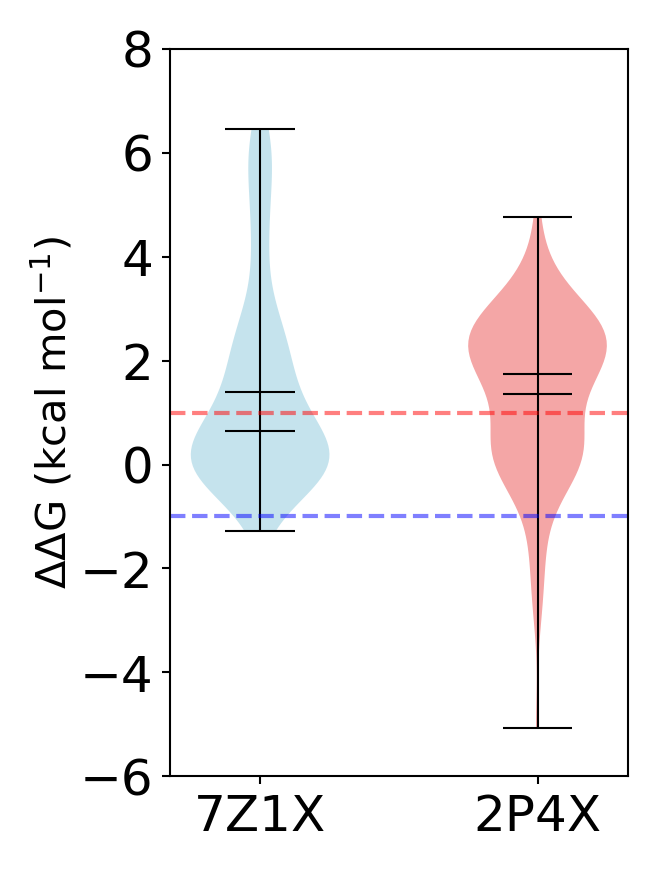

In [103]:
# Create comparison figure with CORRECTED interpretation
fig = plt.figure(figsize=(5*cm, 8*cm),dpi=300)
plt.tick_params(axis='both', which='major', width=0.5, length=2)

# 1. Distribution comparison - Violin plots
tz1a_flat = tz1a_values[~np.isnan(tz1a_values)].flatten()
p42_flat = p42_values[~np.isnan(p42_values)].flatten()

violin_parts = plt.violinplot([tz1a_flat, p42_flat], showmeans=True, showmedians=True)
plt.xticks([1, 2], ['7Z1X', '2P4X'])
plt.yticks(range(-6,10,2))
plt.ylabel('$\Delta\Delta$G (kcal mol$^{-1}$)')
#plt.title('Distribution Comparison of ΔΔG Values',fontsize=8)
plt.axhline(y=1, color='red', linestyle='--', alpha=0.5, label='Destabilizing threshold (+1 kcal/mol)', lw=1)
plt.axhline(y=-1, color='blue', linestyle='--', alpha=0.5, label='Stabilizing threshold (-1 kcal/mol)', lw=1)
#plt.legend(fontsize=5)
plt.ylim(-6,8)

# Color the violins
for pc, color in zip(violin_parts['bodies'], ['lightblue', 'lightcoral']):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
# 设置各种线条的粗细和样式
# 中位数线
violin_parts['cmedians'].set_linewidth(0.5)
violin_parts['cmedians'].set_color('black')

# 平均值线
violin_parts['cmeans'].set_linewidth(0.5)
violin_parts['cmeans'].set_color('black')

# 极值线（最小值/最大值）
violin_parts['cmaxes'].set_linewidth(0.5)
violin_parts['cmaxes'].set_color('black')
violin_parts['cmins'].set_linewidth(0.5)
violin_parts['cmins'].set_color('black')
violin_parts['cbars'].set_linewidth(0.5)  # 中间垂直线
violin_parts['cbars'].set_color('black')

plt.savefig('/home/teliu/work/nanobody/image/hotspot/violin.png',bbox_inches='tight',transparent=True)

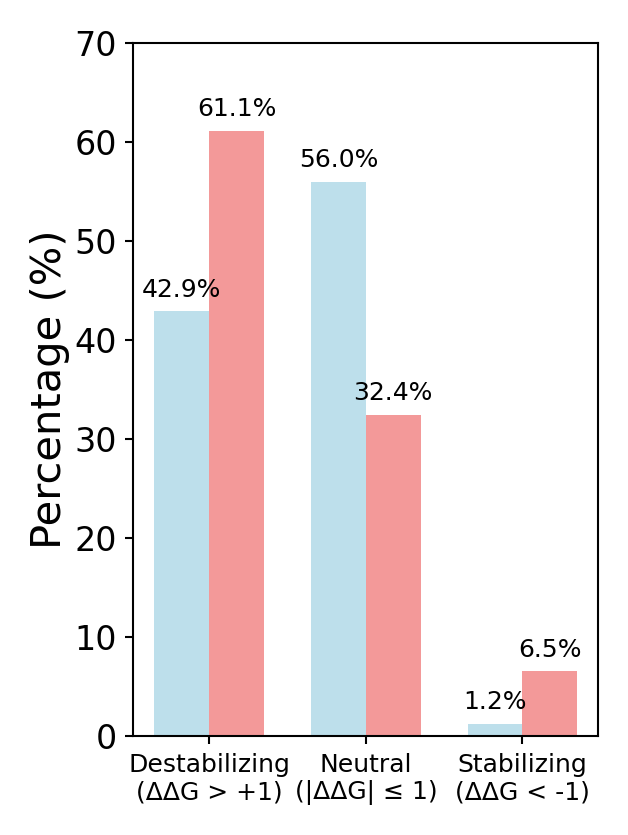

In [31]:
# Create comparison figure with CORRECTED interpretation
fig = plt.figure(figsize=(2,3),dpi=300)
plt.tick_params(axis='both', which='major', width=0.5, length=2)

# 2. Percentage of significant mutations comparison (CORRECTED)
def calculate_percentages(values):
    destabilizing = np.sum(values > 1) / np.sum(~np.isnan(values)) * 100  # Positive = destabilizing
    stabilizing = np.sum(values < -1) / np.sum(~np.isnan(values)) * 100   # Negative = stabilizing
    neutral = 100 - destabilizing - stabilizing
    return [destabilizing, neutral, stabilizing]  # Changed order

tz1a_percentages = calculate_percentages(tz1a_values)
p42_percentages = calculate_percentages(p42_values)

categories = ['Destabilizing\n(ΔΔG > +1)', 'Neutral\n(|ΔΔG| ≤ 1)', 'Stabilizing\n(ΔΔG < -1)']  # Corrected labels
x = np.arange(len(categories))
width = 0.35

plt.bar(x - width/2, tz1a_percentages, width, label='7Z1A', color='lightblue', alpha=0.8)
plt.bar(x + width/2, p42_percentages, width, label='2P42', color='lightcoral', alpha=0.8)

plt.ylabel('Percentage (%)')
#plt.title('Comparison of Mutation Effects')
plt.xticks(x, categories,fontsize=6)
plt.yticks(range(0,80,10),fontsize=8)
plt.ylim(0,70)
#plt.legend(fontsize=6)

# Add value labels on bars
for i, (v1, v2) in enumerate(zip(tz1a_percentages, p42_percentages)):
    plt.text(i - width/2, v1 + 1, f'{v1:.1f}%', ha='center', va='bottom', fontsize=6)
    plt.text(i + width/2, v2 + 1, f'{v2:.1f}%', ha='center', va='bottom', fontsize=6)
plt.savefig('/home/teliu/work/nanobody/image/hotspot/stable.png',bbox_inches='tight',transparent=True)

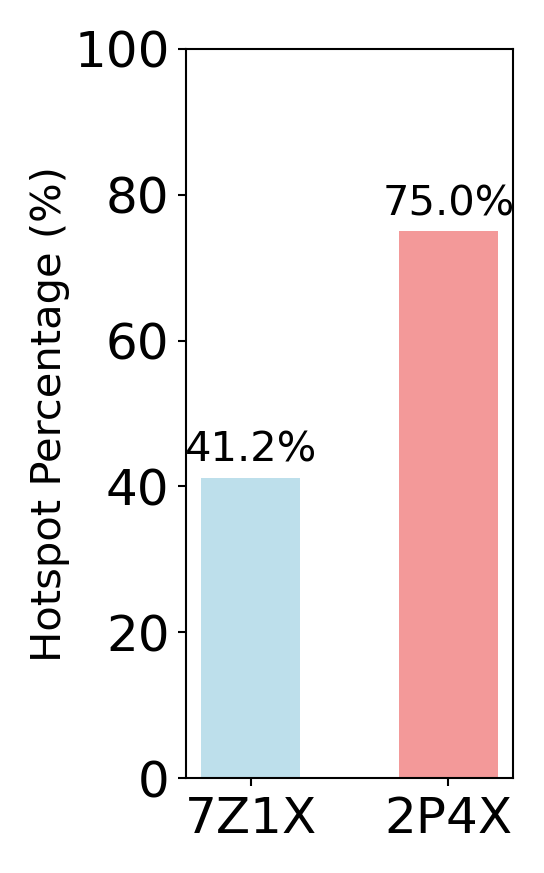

In [104]:
tz1a_avg = np.nanmean(tz1a_values, axis=1)
p42_avg = np.nanmean(p42_values, axis=1)

# Create comparison figure with CORRECTED interpretation
fig = plt.figure(figsize=(5*cm, 7.8*cm),dpi=300)
plt.tick_params(axis='both', which='major', width=0.5, length=2)

# 8. Success rate of alanine scanning (CORRECTED)
# Calculate percentage of residues with |avg ΔΔG| > 1 (significant effects)
tz1a_success = np.sum(np.abs(tz1a_avg) > 1) / len(tz1a_avg) * 100
p42_success = np.sum(np.abs(p42_avg) > 1) / len(p42_avg) * 100

x_pos = np.array([0.5, 0.6])

# 绘制柱子并获取柱子对象
barwidth=0.05
bars = plt.bar(x_pos, [tz1a_success, p42_success], 
               color=['lightblue', 'lightcoral'], alpha=0.8, width=barwidth)

plt.ylabel('Hotspot Percentage (%)')
#plt.title('Percentage of Residues with\n|Average ΔΔG| > 1 kcal/mol', fontsize=8)
plt.xticks(x_pos, ['7Z1X', '2P4X'])
#plt.yticks(fontsize=6)
plt.ylim(0, 100)

# 优化后的标签位置 - 使用柱子的实际位置
for bar, v in zip(bars, [tz1a_success, p42_success]):
    height = bar.get_height()
    x = bar.get_x() + bar.get_width() / 2  # 柱子中心的x坐标
    y = height + 1  # 柱子顶部上方1个单位
    
    plt.text(x, y, f'{v:.1f}%', 
             ha='center', va='bottom', fontsize=10,)  # 可选：加粗字体使其更清晰

plt.tight_layout()
plt.savefig('/home/teliu/work/nanobody/image/hotspot/percentage.png',bbox_inches='tight',transparent=True)

<>:18: SyntaxWarning: invalid escape sequence '\D'
<>:18: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_12075/4229663195.py:18: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('Standard Deviation of $\Delta\Delta$G (kcal mol$^{-1}$)', fontsize=10)
/tmp/ipykernel_12075/4229663195.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot([tz1a_std, p42_std],


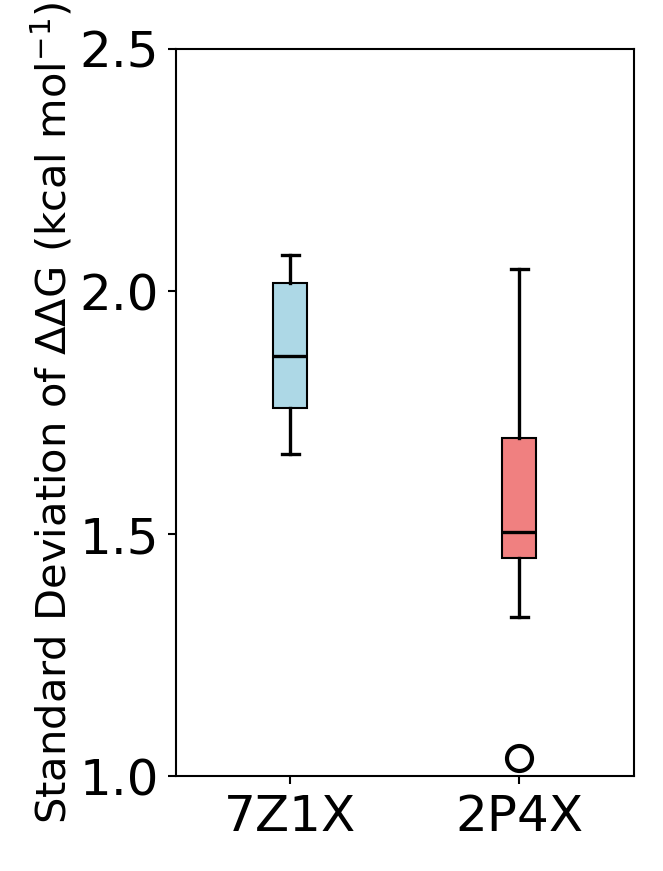

In [105]:
fig = plt.figure(figsize=(5*cm, 8*cm),dpi=300)

# 绘制箱线图并设置样式
bp = plt.boxplot([tz1a_std, p42_std], 
                 labels=['7Z1X', '2P4X'],
                 patch_artist=True,                     # 允许填充箱体颜色
                 boxprops=dict(linewidth=0.5),          # 箱体边框宽度
                 whiskerprops=dict(linewidth=0.8),      # 须线宽度
                 capprops=dict(linewidth=0.8),          # 帽线宽度
                 medianprops=dict(color='black', linewidth=0.8))  # 中位线黑色、细

# 设置箱体填充颜色（可选）
colors = ['lightblue', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

plt.tick_params(axis='both', which='major', width=0.5, length=2)
plt.ylabel('Standard Deviation of $\Delta\Delta$G (kcal mol$^{-1}$)', fontsize=10)
plt.ylim(1, 2.5)
plt.yticks([1, 1.5, 2, 2.5])
plt.savefig('/home/teliu/work/nanobody/image/hotspot/std.png',bbox_inches='tight',transparent=True)

<>:22: SyntaxWarning: invalid escape sequence '\D'
<>:22: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_12075/1287547982.py:22: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('Average $\Delta\Delta$G per residue(kcal mol$^{-1}$)')
/tmp/ipykernel_12075/1287547982.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot([tz1a_avg, p42_avg],


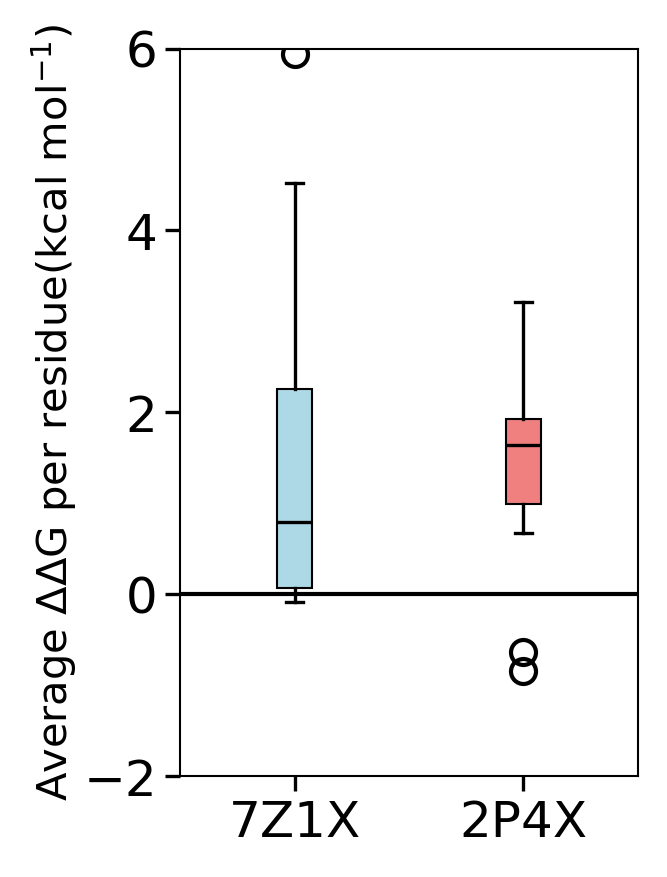

In [106]:
# 3. Average ΔΔG per residue comparison (CORRECTED interpretation)
fig = plt.figure(figsize=(5*cm, 8*cm),dpi=300)
tz1a_avg = np.nanmean(tz1a_values, axis=1)
p42_avg = np.nanmean(p42_values, axis=1)

#plt.boxplot([tz1a_avg, p42_avg], labels=['7Z1A', '2P42'])

# 绘制箱线图并设置样式
bp = plt.boxplot([tz1a_avg, p42_avg], 
                 labels=['7Z1X', '2P4X'],
                 patch_artist=True,                     # 允许填充箱体颜色
                 boxprops=dict(linewidth=0.5),          # 箱体边框宽度
                 whiskerprops=dict(linewidth=0.8),      # 须线宽度
                 capprops=dict(linewidth=0.8),          # 帽线宽度
                 medianprops=dict(color='black', linewidth=0.8))  # 中位线黑色、细

# 设置箱体填充颜色（可选）
colors = ['lightblue', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

plt.ylabel('Average $\Delta\Delta$G per residue(kcal mol$^{-1}$)')
#plt.title('Comparison of Average ΔΔG per Residue\n(Positive = More Destabilizing)')
plt.axhline(y=0, color='black', linestyle='-',linewidth=1)
plt.ylim(-2,6)
plt.savefig('/home/teliu/work/nanobody/image/hotspot/avg.png',bbox_inches='tight',transparent=True)